In [1]:
# Imports & DB Connection
import pandas as pd
import sqlite3

conn = sqlite3.connect('dbs/song_features.db')
query = "SELECT * from song_features"

song_df = pd.read_sql_query(query, conn)
conn.close()
# test we connected and queried correctly
print(song_df.head())

                              track_uri                   track_name  \
0  spotify:track:7KXjTSCq5nL1LoYtL7XAwS                      HUMBLE.   
1  spotify:track:1xznGGDReH1oQq0xzbwXa3                    One Dance   
2  spotify:track:7yyRTcZmCiyzzJlNzGC9Ol  Broccoli (feat. Lil Yachty)   
3  spotify:track:7BKLCZ1jbUBVqRi2FVlTVw                       Closer   
4  spotify:track:3a1lNhkSLSkpJE4MSHpDu9              Congratulations   

        artist_name  in_number_of_playlists  avg_playlist_followers  \
0    Kendrick Lamar                   45394                2.385668   
1             Drake                   41707                2.169924   
2              DRAM                   40659                2.019110   
3  The Chainsmokers                   40629                2.177090   
4       Post Malone                   39577                2.188721   

   avg_position_in_playlist  
0                 54.925431  
1                 44.091112  
2                 44.844315  
3                 48

In [2]:
# get standardized stats for our target features
columns_to_standardize = ['in_number_of_playlists', 'avg_playlist_followers', 'avg_position_in_playlist']
mu_std = song_df[columns_to_standardize].agg(['mean', 'std'])

print(mu_std)

      in_number_of_playlists  avg_playlist_followers  avg_position_in_playlist
mean               28.937368                4.025252                 61.357819
std               355.127951               70.701626                 40.995130


In [3]:
# z-score normalization
for col in columns_to_standardize:
    mu = mu_std.loc['mean', col]
    std = mu_std.loc['std', col]
    # new columns with normalized values
    song_df[f'NORM_{col}'] = (song_df[col] - mu) / std

print(song_df.head())

                              track_uri                   track_name  \
0  spotify:track:7KXjTSCq5nL1LoYtL7XAwS                      HUMBLE.   
1  spotify:track:1xznGGDReH1oQq0xzbwXa3                    One Dance   
2  spotify:track:7yyRTcZmCiyzzJlNzGC9Ol  Broccoli (feat. Lil Yachty)   
3  spotify:track:7BKLCZ1jbUBVqRi2FVlTVw                       Closer   
4  spotify:track:3a1lNhkSLSkpJE4MSHpDu9              Congratulations   

        artist_name  in_number_of_playlists  avg_playlist_followers  \
0    Kendrick Lamar                   45394                2.385668   
1             Drake                   41707                2.169924   
2              DRAM                   40659                2.019110   
3  The Chainsmokers                   40629                2.177090   
4       Post Malone                   39577                2.188721   

   avg_position_in_playlist  NORM_in_number_of_playlists  \
0                 54.925431                   127.742867   
1                 44

In [ ]:
# save new columns to our song_features table
db_connection = sqlite3.connect('dbs/song_features.db')
song_df.to_sql('dbs/song_features', db_connection, if_exists='replace', index=False)

db_connection.close()

In [7]:
# ------------------------------------------------ Clustering ------------------------------------------------
# Imports and setup for clustering
from sklearn.cluster import KMeans
import pandas as pd
import sqlite3

conn = sqlite3.connect('dbs/song_features.db')
song_df = pd.read_sql_query("SELECT * from song_features", conn)
conn.close()

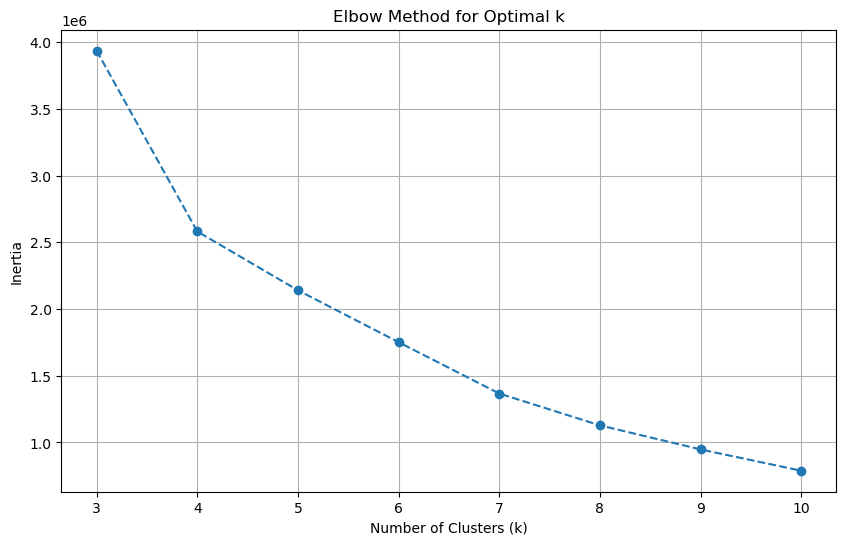

In [ ]:
# -- Elbow method-ing --   From this, k did indeed seem to be the best choice.
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# -- Chosen K value --
# k = 5
# --------------------

conn = sqlite3.connect('dbs/song_features.db')
song_df = pd.read_sql_query("SELECT * from song_features", conn)
conn.close()

clustered_features = song_df[['NORM_in_number_of_playlists', 'NORM_avg_playlist_followers', 'NORM_avg_position_in_playlist']]

inertias = []
k_range = range(3, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustered_features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
# -- Chosen K value -- 4 was the best choice from the elbow method and was expected in our initial plan.
k = 4
# --------------------

clustered_features = song_df[['NORM_in_number_of_playlists', 'NORM_avg_playlist_followers', 'NORM_avg_position_in_playlist']]
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(clustered_features)

song_df['cluster'] = kmeans.labels_
features_to_analyze = ['in_number_of_playlists', 'avg_playlist_followers', 'avg_position_in_playlist', 'cluster']
analysis_df = song_df[features_to_analyze]

cluster_summary = analysis_df.groupby('cluster').agg(['mean', 'size'])
print(cluster_summary)

# -- Save to table --
conn = sqlite3.connect('dbs/song_features.db')
song_df.to_sql('song_features', conn, if_exists='replace', index=False)
conn.close()

# From the output, each cluster may be described as follows:
# Cluster 0: General — High playlist avg., typical avg. followers, high avg. position.
#            These songs are the 'typical' song on Spotify. They likely make up most of any playlist, popular and personal alike, explaining the low avg. followers.
#            The high avg. position may indicate playlists are built upon a large set of 'typical' songs, with niche and curated songs added later.
#
# Cluster 1: Niche — Low playlist count, typical avg. followers, low avg. position. 
#            These songs don't reach mainstream appeal. There's a lot of these (500k+), but they appear personal playlists. Likely in niche genres.
#            The low avg. position indicates that these songs are likely not staples—they are typically discovered later in a listener's journey.
#
# Cluster 2: Mainstream — Very high playlist avg., typical avg. followers, high avg. position. 
#            These are rare songs (2035 count) that are popular and wide-spread even in personal playlists, explaining to the ~2.5 avg. followers.
#            The high avg. position indicates these songs are some of the first added when a listener starts a playlist.
#
# Cluster 3: Curated — Low playlist count (curated by Spotify), very high avg. followers, typical avg. position.
#            These are songs that haven't met mainstream popularity yet, but have been curated by Spotify such as one of their "Mixes" or "New Music Friday" playlists.

        in_number_of_playlists          avg_playlist_followers           \
                          mean     size                   mean     size   
cluster                                                                   
0                    25.913730  1713638               2.903774  1713638   
1                     3.283189   545869               3.421173   545869   
2                  9465.759214     2035               2.477831     2035   
3                     4.017333      750            3010.298177      750   

        avg_position_in_playlist           
                            mean     size  
cluster                                    
0                      43.089920  1713638  
1                     118.719741   545869  
2                      51.455640     2035  
3                      78.187704      750  


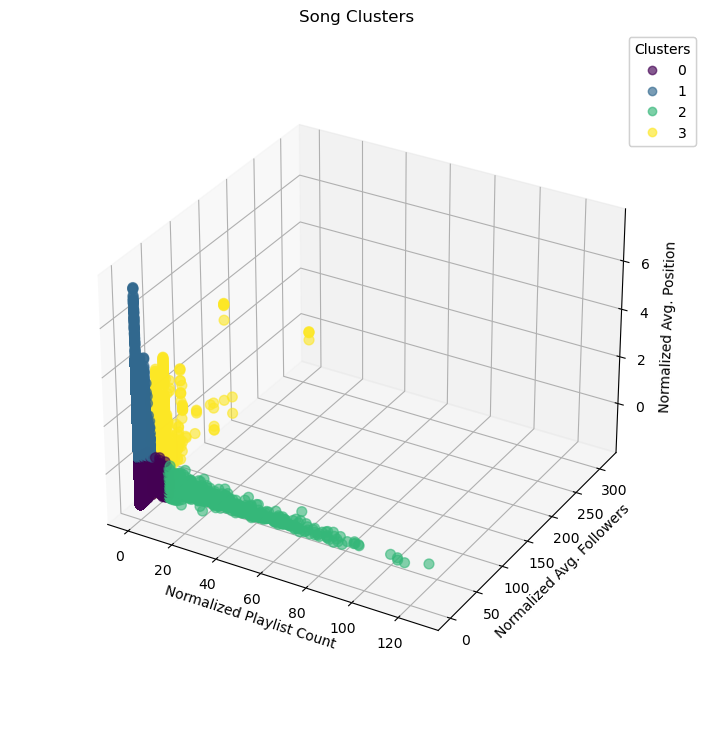

In [25]:
# Clustering Visualization
import mpl_toolkits.mplot3d as Axes3D

db_conn = sqlite3.connect('dbs/song_features.db')
query = "SELECT * FROM song_features"
songs_df = pd.read_sql_query(query, db_conn)
db_conn.close()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(songs_df['NORM_in_number_of_playlists'], 
                    songs_df['NORM_avg_playlist_followers'], 
                    songs_df['NORM_avg_position_in_playlist'], 
                    c=songs_df['cluster'], 
                    cmap='viridis', 
                    s=50, alpha=0.6)

ax.set_title('Song Clusters')
ax.set_xlabel('Normalized Playlist Count')
ax.set_ylabel('Normalized Avg. Followers')
ax.set_zlabel('Normalized Avg. Position')

ax.add_artist(ax.legend(*scatter.legend_elements(), title="Clusters"))

ax.set_box_aspect(None, zoom=0.85)
plt.show()